# nb25 - Pure-gNFW fit of (B, sigma_lnY) with the ell>100 cut: contours + best-fit PS

Fit the FLAMINGO tSZ auto-spectrum keeping only the **last 9 of the 18 bins**
(all ell>100), cosmology fixed to D3A, sampling the hydrostatic mass bias **B**
(uniform) and the intrinsic lognormal scatter **sigma_lnY** with a Gaussian prior
N(0.173, 0.023). Chains live in `chains/mcmc_pureGNFW_fitB_scatter_ellgt100/`
(produced by `cobaya/run_chains.sh`).

This notebook (1) draws the getdist posterior contours of (B, sigma_lnY) for the
full-sky and q>{5,10,20,50} cuts, and (2) overlays the best-fit hmfast tSZ power
spectrum on the ell>100 datapoints.

In [1]:
import os, sys
os.environ["HMFAST_COBAYA_USE_GPU"] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

REPO = "/scratch/scratch-lxu/flamingo_repo"
sys.path.insert(0, os.path.join(REPO, "cobaya", "theory"))   # shared theory helpers

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import jax.numpy as jnp
from getdist import loadMCSamples, plots

from hmfast_tsz_iter_cprofile import (
    _FID, _bin_to_18, _ELL_MIN, _ELL_MAX, _A_S_REF, _LN1E10_A_S_REF)
from hmfast.cosmology import Cosmology
from hmfast.halos import HaloModel
from hmfast.halos.mass_definition import MassDefinition
from hmfast.halos.profiles import GNFWPressureProfile
from hmfast.tracers import tSZTracer
from hmfast.tracers.tsz_completeness import (
    build_snr_grid, conditional_An_undetected, load_sigma_y0_curve)

## Configuration

In [2]:
CHAIN_DIR = os.path.join(REPO, "chains", "mcmc_pureGNFW_fitB_scatter_ellgt100")
DATA_DIR  = os.path.join(REPO, "data", "tsz_yy_snr_datapoints")
KEEP = 9                                   # last 9 of 18 bins -> ell > 100

D3A = dict(sigma8=0.811, omega_cdm=0.118729, omega_b=0.022539,
           H0=68.1, n_s=0.967, tau_reio=0.0544)
ARN = dict(P0=8.403, c500=1.177, alpha=1.051, beta=5.4905, gamma=0.3081)

CUTS = [
    dict(tag="fullsky", label="Full sky", root="yy_fullsky_fitB_scatter", q_cat=1.0e9,
         a_sz_sr=-4.277981997317676, alpha_sr=0.952057528307069, b_sr=1.25,
         data="Dl_yy_obscat_fullsky_binned_18.txt", cov="cov_full_obscat_fullsky_Dl_yy_binned_18.npy"),
    dict(tag="qgt5", label="q > 5", root="yy_qgt5_fitB_scatter", q_cat=5.0,
         a_sz_sr=-4.277981997317676, alpha_sr=0.952057528307069, b_sr=1.25,
         data="Dl_yy_itercat_qgt5_binned_18.txt", cov="cov_full_itercat_qgt5_Dl_yy_binned_18.npy"),
    dict(tag="qgt10", label="q > 10", root="yy_qgt10_fitB_scatter", q_cat=10.0,
         a_sz_sr=-4.270843927746104, alpha_sr=0.9444223458089253, b_sr=1.25,
         data="Dl_yy_itercat_qgt10_binned_18.txt", cov="cov_full_itercat_qgt10_Dl_yy_binned_18.npy"),
    dict(tag="qgt20", label="q > 20", root="yy_qgt20_fitB_scatter", q_cat=20.0,
         a_sz_sr=-4.251361373150767, alpha_sr=0.9236653041902941, b_sr=1.25,
         data="Dl_yy_itercat_qgt20_binned_18.txt", cov="cov_full_itercat_qgt20_Dl_yy_binned_18.npy"),
    dict(tag="qgt50", label="q > 50", root="yy_qgt50_fitB_scatter", q_cat=50.0,
         a_sz_sr=-4.212273738811673, alpha_sr=0.8765101646932605, b_sr=1.25,
         data="Dl_yy_itercat_qgt50_binned_18.txt", cov="cov_full_itercat_qgt50_Dl_yy_binned_18.npy"),
]
colors = [mcolors.to_hex(c) for c in plt.cm.plasma(np.linspace(0, 0.85, len(CUTS)))]
OUTDIR = os.path.join(REPO, "figures", "nb_scatter_ellgt100")
os.makedirs(OUTDIR, exist_ok=True)

## Load chains and best-fit (B, sigma_lnY)

Best fit = maximum-a-posteriori sample (minimum -log posterior).

In [3]:
samples, labels, bestfit = [], [], {}
for cut in CUTS:
    s = loadMCSamples(os.path.join(CHAIN_DIR, cut["root"]), settings={"ignore_rows": 0.3})
    s.root = cut["label"]
    samples.append(s); labels.append(cut["label"])
    p = s.getParams(); i = int(np.argmin(s.loglikes))
    bestfit[cut["tag"]] = dict(B=float(p.B[i]), sigma_lnY=float(p.sigma_lnY[i]))
    print(f"{cut['label']:8s}  B = {s.mean('B'):.4f} +/- {s.std('B'):.4f}   "
          f"sigma_lnY = {s.mean('sigma_lnY'):.4f} +/- {s.std('sigma_lnY'):.4f}   "
          f"(MAP: B={bestfit[cut['tag']]['B']:.4f}, s={bestfit[cut['tag']]['sigma_lnY']:.4f})")

Full sky  B = 1.1323 +/- 0.0082   sigma_lnY = 0.1728 +/- 0.0246   (MAP: B=1.1309, s=0.1718)
q > 5     B = 1.0837 +/- 0.0015   sigma_lnY = 0.0562 +/- 0.0122   (MAP: B=1.0837, s=0.0566)
q > 10    B = 1.1110 +/- 0.0023   sigma_lnY = 0.0769 +/- 0.0146   (MAP: B=1.1111, s=0.0791)
q > 20    B = 1.1234 +/- 0.0040   sigma_lnY = 0.1310 +/- 0.0190   (MAP: B=1.1226, s=0.1274)
q > 50    B = 1.1335 +/- 0.0065   sigma_lnY = 0.1601 +/- 0.0225   (MAP: B=1.1322, s=0.1587)


## Posterior contours

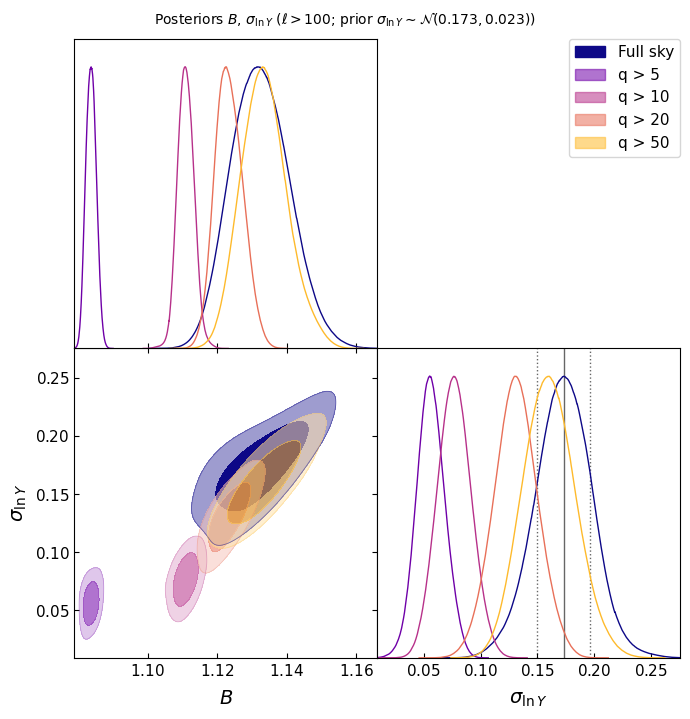

In [4]:
g = plots.get_subplot_plotter(width_inch=7.0)
g.settings.alpha_filled_add = 0.55; g.settings.legend_fontsize = 11
g.triangle_plot(samples, ["B", "sigma_lnY"], filled=True, contour_colors=colors,
                legend_labels=labels, legend_loc="upper right")
ax_s = g.subplots[1, 1]
for v, ls in [(0.173, "-"), (0.150, ":"), (0.196, ":")]:
    ax_s.axvline(v, color="0.4", lw=1.0, ls=ls, zorder=0)   # sigma_lnY prior N(0.173,0.023)
g.fig.suptitle(r"Posteriors $B$, $\sigma_{\ln Y}$ ($\ell>100$; prior "
               r"$\sigma_{\ln Y}\sim\mathcal{N}(0.173,0.023)$)", fontsize=10, y=1.02)
g.export(os.path.join(OUTDIR, "posteriors_B_sigmalnY_ellgt100.pdf"))
g.export(os.path.join(OUTDIR, "posteriors_B_sigmalnY_ellgt100.png"))
plt.show()

## hmfast best-fit tSZ power spectrum

Same `HMFastTSZIterGNFW` physics as the chains: Arnaud-2010 gNFW, D3A cosmology,
z up to 3.0. The masking now carries the fitted intrinsic scatter sigma_lnY via
`conditional_An_undetected` (for full sky q_cat -> inf this is the exp(2 sigma^2)
boost; for the q-cuts it is the scatter-convolved completeness).

In [5]:
m = jnp.geomspace(1e10, 10**15.5, 64)
z = jnp.geomspace(0.005, 3.0, 96)
ell_int = jnp.geomspace(float(_ELL_MIN[0]), float(_ELL_MAX[-1]), 50)
ell_np = np.asarray(ell_int)

cosmo_seed = Cosmology(emulator_set="lcdm:v1")
hm_seed = HaloModel(cosmology=cosmo_seed.update(**_FID),
                    mass_definition=MassDefinition(500, "critical"), convert_masses=True)
prof_seed = GNFWPressureProfile(B=1.4, **ARN)
tsz_seed = tSZTracer(profile=prof_seed)
coeff, _ = load_sigma_y0_curve()

_c = cosmo_seed.update(H0=D3A["H0"], omega_cdm=D3A["omega_cdm"], omega_b=D3A["omega_b"],
                       ln1e10A_s=_LN1E10_A_S_REF, n_s=D3A["n_s"], tau_reio=D3A["tau_reio"])
ln1e10As = float(np.log(1e10 * _A_S_REF * (D3A["sigma8"] / float(np.asarray(_c.sigma8(0.0)))) ** 2))
cosmo_D3A = cosmo_seed.update(H0=D3A["H0"], omega_cdm=D3A["omega_cdm"], omega_b=D3A["omega_b"],
                              ln1e10A_s=ln1e10As, n_s=D3A["n_s"], tau_reio=D3A["tau_reio"])
hm_D3A = hm_seed.update(cosmology=cosmo_D3A)

def predict_dl(cut, B, sigma_lnY):
    snr = build_snr_grid(hm_seed, m, z, cut["a_sz_sr"], cut["alpha_sr"], cut["b_sr"], coeff=coeff)
    tsz = tsz_seed.update(profile=prof_seed.update(B=B, **ARN))
    mask1 = conditional_An_undetected(snr, sigma_lnY=sigma_lnY, q_cat=cut["q_cat"], n_power=2)
    mask2 = conditional_An_undetected(snr, sigma_lnY=sigma_lnY, q_cat=cut["q_cat"], n_power=1)
    cl1 = hm_D3A.cl_1h_masked(tsz, None, ell_int, m, z, mask1)
    cl2 = hm_D3A.cl_2h_masked(tsz, None, ell_int, m, z, mask2)
    return _bin_to_18(ell_np, np.asarray(cl1)) + _bin_to_18(ell_np, np.asarray(cl2))   # 18 bins

In [6]:
from scipy.stats import chi2 as _chi2dist
results = {}
print(f"{'cut':8s} {'B':>7s} {'s_lnY':>7s} {'chi2':>8s} {'dof':>4s} {'PTE':>9s}")
for cut in CUTS:
    bf = bestfit[cut["tag"]]
    Dl_th_full = np.asarray(predict_dl(cut, bf["B"], bf["sigma_lnY"]))
    D = np.loadtxt(os.path.join(DATA_DIR, cut["data"]))
    cov = np.load(os.path.join(DATA_DIR, cut["cov"]))
    sl = slice(18 - KEEP, 18)
    ell = D[sl, 0]; Dl_obs = D[sl, 1]; C = cov[sl, sl]
    Dl_th = Dl_th_full[sl]
    err = np.sqrt(np.diag(C))
    resid = Dl_obs - Dl_th
    chi2 = float(resid @ np.linalg.inv(C) @ resid); dof = KEEP - 2  # 2 fitted params
    results[cut["tag"]] = dict(ell=ell, Dl_obs=Dl_obs, err=err, Dl_th=Dl_th, chi2=chi2, dof=dof)
    print(f"{cut['label']:8s} {bf['B']:7.4f} {bf['sigma_lnY']:7.4f} {chi2:8.2f} {dof:4d} "
          f"{_chi2dist.sf(chi2, dof):9.2e}")

cut            B   s_lnY     chi2  dof       PTE
Full sky  1.1309  0.1718     5.74    7  5.70e-01
q > 5     1.0837  0.0566  1715.70    7  0.00e+00
q > 10    1.1111  0.0791   680.31    7 1.21e-142
q > 20    1.1226  0.1274   286.44    7  4.74e-58
q > 50    1.1322  0.1587    51.47    7  7.43e-09


## Best-fit PS vs datapoints (ell>100)

saved -> /scratch/scratch-lxu/flamingo_repo/figures/nb_scatter_ellgt100


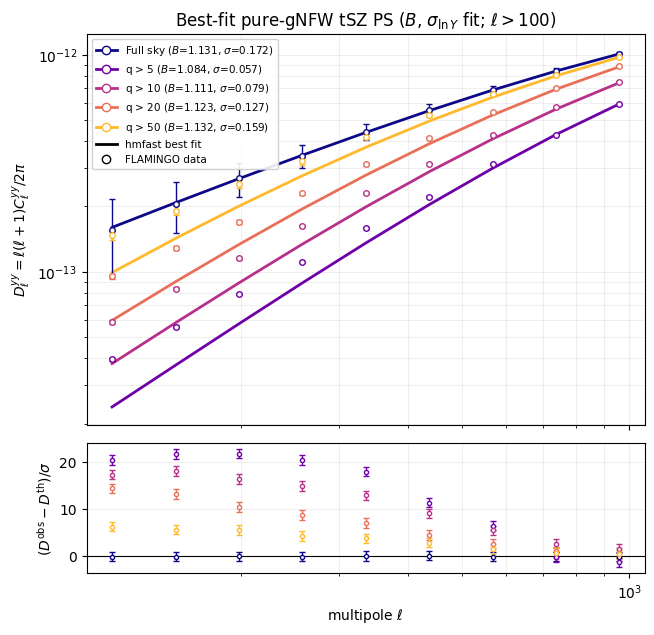

: 

In [ ]:
from matplotlib.lines import Line2D
fig, (ax, axr) = plt.subplots(2, 1, figsize=(7.2, 7.0), sharex=True,
                              gridspec_kw=dict(height_ratios=[3, 1], hspace=0.07))
for cut, col in zip(CUTS, colors):
    r = results[cut["tag"]]
    ax.plot(r["ell"], r["Dl_th"], "-", color=col, lw=2, zorder=3)
    ax.errorbar(r["ell"], r["Dl_obs"], yerr=r["err"], fmt="o", color=col, ms=4,
                capsize=2, elinewidth=1, mfc="white", zorder=4)
    axr.errorbar(r["ell"], (r["Dl_obs"] - r["Dl_th"]) / r["err"], yerr=1.0, fmt="o",
                 color=col, ms=3, capsize=2, elinewidth=1, mfc="white")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_ylabel(r"$D_\ell^{yy}=\ell(\ell+1)C_\ell^{yy}/2\pi$")
ax.set_title(r"Best-fit pure-gNFW tSZ PS ($B$, $\sigma_{\ln Y}$ fit; $\ell>100$)")
ax.grid(True, which="both", alpha=0.2)
handles = [Line2D([0],[0],color=c,marker="o",mfc="white",lw=2,
                  label=rf"{cut['label']} ($B$={bestfit[cut['tag']]['B']:.3f}, "
                        rf"$\sigma$={bestfit[cut['tag']]['sigma_lnY']:.3f})")
           for cut,c in zip(CUTS,colors)]
handles += [Line2D([0],[0],color="k",lw=2,label="hmfast best fit"),
            Line2D([0],[0],color="k",marker="o",mfc="white",ls="none",label="FLAMINGO data")]
ax.legend(handles=handles, fontsize=7.5, loc="upper left", framealpha=0.9)
axr.axhline(0, color="k", lw=0.8)
axr.set_ylabel(r"$(D^{\rm obs}-D^{\rm th})/\sigma$"); axr.set_xlabel(r"multipole $\ell$")
axr.grid(True, which="both", alpha=0.2)
fig.savefig(os.path.join(OUTDIR, "bestfit_tsz_ps_ellgt100.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(OUTDIR, "bestfit_tsz_ps_ellgt100.pdf"), bbox_inches="tight")
print("saved ->", OUTDIR)
plt.show()

## Notes

- Only ell>100 (the last 9 bins) and the trailing 9x9 block of the `cov_full`
  covariance enter the fit; B and sigma_lnY are the only free parameters.
- B and sigma_lnY are positively correlated: a higher amplitude can be reached
  either by raising B (less mass bias suppression... lower Y) -- no: larger B
  lowers Y, but larger sigma_lnY boosts the 1-halo term by exp(2 sigma^2), so the
  contour tilts so that the masked cuts with little detected signal pull
  sigma_lnY below the prior while the full sky stays near it.
- dof = 9 - 2 (two fitted parameters).